**Protein Design Example**

This example notebook is adapted from Sergei Ovchinnikov's ColabDesign notebook. The notebook is an interactive implementation of RFdiffusion, proteinMPNN and ColabFold.

RFdiffusion is a method for structure generation, with or without conditional information (a motif, target etc). It can perform a whole range of protein design challenges as we have outlined in the RFdiffusion [manuscript](https://www.biorxiv.org/content/10.1101/2022.12.09.519842v2).

For **instructions**, see end of Notebook.



In [ ]:
import torch
torch.serialization.add_safe_globals([slice])

In [ ]:
#@title setup RFdiffusion and ColabDesign (~3min)
#You should not need to change anything from this code block
%%time
import os, time, signal
import sys, random, string, re
if not os.path.isdir("params"):
  os.system("apt-get install aria2")
  os.system("mkdir params")
  # send param download into background
  os.system("(\
  aria2c -q -x 16 https://files.ipd.uw.edu/krypton/schedules.zip; \
  aria2c -q -x 16 http://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Base_ckpt.pt; \
  aria2c -q -x 16 http://files.ipd.uw.edu/pub/RFdiffusion/e29311f6f1bf1af907f9ef9f44b8328b/Complex_base_ckpt.pt; \
  aria2c -q -x 16 http://files.ipd.uw.edu/pub/RFdiffusion/f572d396fae9206628714fb2ce00f72e/Complex_beta_ckpt.pt; \
  aria2c -q -x 16 https://storage.googleapis.com/alphafold/alphafold_params_2022-12-06.tar; \
  tar -xf alphafold_params_2022-12-06.tar -C params; \
  touch params/done.txt) &")

if not os.path.isdir("RFdiffusion"):
  print("installing RFdiffusion...")
  os.system("git clone https://github.com/sokrypton/RFdiffusion.git")
  os.system("pip install jedi omegaconf hydra-core icecream pyrsistent pynvml decorator")
  os.system("pip install git+https://github.com/NVIDIA/dllogger#egg=dllogger")
  # 17Mar2024: adding --no-dependencies to avoid installing nvidia-cuda-* dependencies
  os.system("pip install --no-dependencies dgl==2.0.0 -f https://data.dgl.ai/wheels/cu121/repo.html")
  os.system("pip install --no-dependencies e3nn==0.3.3 opt_einsum_fx")
  os.system("cd RFdiffusion/env/SE3Transformer; pip install .")
  os.system("wget -qnc https://files.ipd.uw.edu/krypton/ananas")
  os.system("chmod +x ananas")

if not os.path.isdir("colabdesign"):
  print("installing ColabDesign...")
  os.system("pip -q install git+https://github.com/sokrypton/ColabDesign.git")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabdesign colabdesign")

if not os.path.isdir("RFdiffusion/models"):
  print("downloading RFdiffusion params...")
  os.system("mkdir RFdiffusion/models")
  models = ["Base_ckpt.pt","Complex_base_ckpt.pt","Complex_beta_ckpt.pt"]
  for m in models:
    while os.path.isfile(f"{m}.aria2"):
      time.sleep(5)
  os.system(f"mv {' '.join(models)} RFdiffusion/models")
  os.system("unzip schedules.zip; rm schedules.zip")

if 'RFdiffusion' not in sys.path:
  os.environ["DGLBACKEND"] = "pytorch"
  sys.path.append('RFdiffusion')

from google.colab import files
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import ipywidgets as widgets
import py3Dmol

from inference.utils import parse_pdb
from colabdesign.rf.utils import get_ca
from colabdesign.rf.utils import fix_contigs, fix_partial_contigs, fix_pdb, sym_it
from colabdesign.shared.protein import pdb_to_string
from colabdesign.shared.plot import plot_pseudo_3D

def get_pdb(pdb_code=None):
  if pdb_code is None or pdb_code == "":
    upload_dict = files.upload()
    pdb_string = upload_dict[list(upload_dict.keys())[0]]
    with open("tmp.pdb","wb") as out: out.write(pdb_string)
    return "tmp.pdb"
  elif os.path.isfile(pdb_code):
    return pdb_code
  elif len(pdb_code) == 4:
    if not os.path.isfile(f"{pdb_code}.pdb1"):
      os.system(f"wget -qnc https://files.rcsb.org/download/{pdb_code}.pdb1.gz")
      os.system(f"gunzip {pdb_code}.pdb1.gz")
    return f"{pdb_code}.pdb1"
  else:
    os.system(f"wget -qnc https://alphafold.ebi.ac.uk/files/AF-{pdb_code}-F1-model_v3.pdb")
    return f"AF-{pdb_code}-F1-model_v3.pdb"

def run_ananas(pdb_str, path, sym=None):
  pdb_filename = f"outputs/{path}/ananas_input.pdb"
  out_filename = f"outputs/{path}/ananas.json"
  with open(pdb_filename,"w") as handle:
    handle.write(pdb_str)

  cmd = f"./ananas {pdb_filename} -u -j {out_filename}"
  if sym is None: os.system(cmd)
  else: os.system(f"{cmd} {sym}")

  # parse results
  try:
    out = json.loads(open(out_filename,"r").read())
    results,AU = out[0], out[-1]["AU"]
    group = AU["group"]
    chains = AU["chain names"]
    rmsd = results["Average_RMSD"]
    print(f"AnAnaS detected {group} symmetry at RMSD:{rmsd:.3}")

    C = np.array(results['transforms'][0]['CENTER'])
    A = [np.array(t["AXIS"]) for t in results['transforms']]

    # apply symmetry and filter to the asymmetric unit
    new_lines = []
    for line in pdb_str.split("\n"):
      if line.startswith("ATOM"):
        chain = line[21:22]
        if chain in chains:
          x = np.array([float(line[i:(i+8)]) for i in [30,38,46]])
          if group[0] == "c":
            x = sym_it(x,C,A[0])
          if group[0] == "d":
            x = sym_it(x,C,A[1],A[0])
          coord_str = "".join(["{:8.3f}".format(a) for a in x])
          new_lines.append(line[:30]+coord_str+line[54:])
      else:
        new_lines.append(line)
    return results, "\n".join(new_lines)

  except:
    return None, pdb_str

def run(command, steps, num_designs=1, visual="none"):

  def run_command_and_get_pid(command):
    pid_file = '/dev/shm/pid'
    os.system(f'nohup {command} & echo $! > {pid_file}')
    with open(pid_file, 'r') as f:
      pid = int(f.read().strip())
    os.remove(pid_file)
    return pid
  def is_process_running(pid):
    try:
      os.kill(pid, 0)
    except OSError:
      return False
    else:
      return True

  run_output = widgets.Output()
  progress = widgets.FloatProgress(min=0, max=1, description='running', bar_style='info')
  display(widgets.VBox([progress, run_output]))

  # clear previous run
  for n in range(steps):
    if os.path.isfile(f"/dev/shm/{n}.pdb"):
      os.remove(f"/dev/shm/{n}.pdb")

  pid = run_command_and_get_pid(command)
  try:
    fail = False
    for _ in range(num_designs):

      # for each step check if output generated
      for n in range(steps):
        wait = True
        while wait and not fail:
          time.sleep(0.1)
          if os.path.isfile(f"/dev/shm/{n}.pdb"):
            pdb_str = open(f"/dev/shm/{n}.pdb").read()
            if pdb_str[-3:] == "TER":
              wait = False
            elif not is_process_running(pid):
              fail = True
          elif not is_process_running(pid):
            fail = True

        if fail:
          progress.bar_style = 'danger'
          progress.description = "failed"
          break

        else:
          progress.value = (n+1) / steps
          if visual != "none":
            with run_output:
              run_output.clear_output(wait=True)
              if visual == "image":
                xyz, bfact = get_ca(f"/dev/shm/{n}.pdb", get_bfact=True)
                fig = plt.figure()
                fig.set_dpi(100);fig.set_figwidth(6);fig.set_figheight(6)
                ax1 = fig.add_subplot(111);ax1.set_xticks([]);ax1.set_yticks([])
                plot_pseudo_3D(xyz, c=bfact, cmin=0.5, cmax=0.9, ax=ax1)
                plt.show()
              if visual == "interactive":
                view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
                view.addModel(pdb_str,'pdb')
                view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':0.5,'max':0.9}}})
                view.zoomTo()
                view.show()
        if os.path.exists(f"/dev/shm/{n}.pdb"):
          os.remove(f"/dev/shm/{n}.pdb")
      if fail:
        progress.bar_style = 'danger'
        progress.description = "failed"
        break

    while is_process_running(pid):
      time.sleep(0.1)

  except KeyboardInterrupt:
    os.kill(pid, signal.SIGTERM)
    progress.bar_style = 'danger'
    progress.description = "stopped"

def run_diffusion(contigs, path, pdb=None, iterations=50,
                  symmetry="none", order=1, hotspot=None,
                  chains=None, add_potential=False, partial_T="auto",
                  num_designs=1, use_beta_model=False, visual="none"):

  full_path = f"outputs/{path}"
  os.makedirs(full_path, exist_ok=True)
  opts = [f"inference.output_prefix={full_path}",
          f"inference.num_designs={num_designs}"]

  if chains == "": chains = None

  # determine symmetry type
  if symmetry in ["auto","cyclic","dihedral"]:
    if symmetry == "auto":
      sym, copies = None, 1
    else:
      sym, copies = {"cyclic":(f"c{order}",order),
                     "dihedral":(f"d{order}",order*2)}[symmetry]
  else:
    symmetry = None
    sym, copies = None, 1

  # determine mode
  contigs = contigs.replace(","," ").replace(":"," ").split()
  is_fixed, is_free = False, False
  fixed_chains = []
  for contig in contigs:
    for x in contig.split("/"):
      a = x.split("-")[0]
      if a[0].isalpha():
        is_fixed = True
        if a[0] not in fixed_chains:
          fixed_chains.append(a[0])
      if a.isnumeric():
        is_free = True
  if len(contigs) == 0 or not is_free:
    mode = "partial"
  elif is_fixed:
    mode = "fixed"
  else:
    mode = "free"

  # fix input contigs
  if mode in ["partial","fixed"]:
    pdb_str = pdb_to_string(get_pdb(pdb), chains=chains)
    if symmetry == "auto":
      a, pdb_str = run_ananas(pdb_str, path)
      if a is None:
        print(f'ERROR: no symmetry detected')
        symmetry = None
        sym, copies = None, 1
      else:
        if a["group"][0] == "c":
          symmetry = "cyclic"
          sym, copies = a["group"], int(a["group"][1:])
        elif a["group"][0] == "d":
          symmetry = "dihedral"
          sym, copies = a["group"], 2 * int(a["group"][1:])
        else:
          print(f'ERROR: the detected symmetry ({a["group"]}) not currently supported')
          symmetry = None
          sym, copies = None, 1

    elif mode == "fixed":
      pdb_str = pdb_to_string(pdb_str, chains=fixed_chains)

    pdb_filename = f"{full_path}/input.pdb"
    with open(pdb_filename, "w") as handle:
      handle.write(pdb_str)

    parsed_pdb = parse_pdb(pdb_filename)
    opts.append(f"inference.input_pdb={pdb_filename}")
    if mode in ["partial"]:
      if partial_T == "auto":
        iterations = int(80 * (iterations / 200))
      else:
        iterations = int(partial_T)
      opts.append(f"diffuser.partial_T={iterations}")
      contigs = fix_partial_contigs(contigs, parsed_pdb)
    else:
      opts.append(f"diffuser.T={iterations}")
      contigs = fix_contigs(contigs, parsed_pdb)
  else:
    opts.append(f"diffuser.T={iterations}")
    parsed_pdb = None
    contigs = fix_contigs(contigs, parsed_pdb)

  if hotspot is not None and hotspot != "":
    hotspot = ",".join(hotspot.replace(","," ").split())
    opts.append(f"ppi.hotspot_res='[{hotspot}]'")

  # setup symmetry
  if sym is not None:
    sym_opts = ["--config-name symmetry", f"inference.symmetry={sym}"]
    if add_potential:
      sym_opts += ["'potentials.guiding_potentials=[\"type:olig_contacts,weight_intra:1,weight_inter:0.1\"]'",
                   "potentials.olig_intra_all=True","potentials.olig_inter_all=True",
                   "potentials.guide_scale=2","potentials.guide_decay=quadratic"]
    opts = sym_opts + opts
    contigs = sum([contigs] * copies,[])

  opts.append(f"'contigmap.contigs=[{' '.join(contigs)}]'")
  opts += ["inference.dump_pdb=True","inference.dump_pdb_path='/dev/shm'"]
  if use_beta_model:
    opts += ["inference.ckpt_override_path=./RFdiffusion/models/Complex_beta_ckpt.pt"]

  print("mode:", mode)
  print("output:", full_path)
  print("contigs:", contigs)

  opts_str = " ".join(opts)
  cmd = f"./RFdiffusion/run_inference.py {opts_str}"
  print(cmd)

  # RUN
  run(cmd, iterations, num_designs, visual=visual)

  # fix pdbs
  for n in range(num_designs):
    pdbs = [f"outputs/traj/{path}_{n}_pX0_traj.pdb",
            f"outputs/traj/{path}_{n}_Xt-1_traj.pdb",
            f"{full_path}_{n}.pdb"]
    for pdb in pdbs:
      with open(pdb,"r") as handle: pdb_str = handle.read()
      with open(pdb,"w") as handle: handle.write(fix_pdb(pdb_str, contigs))

  return contigs, copies

/content/RFdiffusion/Track_module.py:241: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


CPU times: user 1.23 s, sys: 215 ms, total: 1.44 s
Wall time: 2.46 s


In [ ]:
# FIX _wigner.py: inject `import torch` and `add_safe_globals` at top
!sed -i '1iimport torch\ntorch.serialization.add_safe_globals([slice])' /usr/local/lib/python3.11/dist-packages/e3nn/o3/_wigner.py

# FIX torch.load(...) line with weights_only=False
!sed -i "s@_Jd, _W3j_flat, _W3j_indices = torch.load(.*)@_Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'), weights_only=False)@" /usr/local/lib/python3.11/dist-packages/e3nn/o3/_wigner.py

In [ ]:
%%time
#@title run **ProteinMPNN** to generate a sequence and **AlphaFold** to validate
#ProteinMPNN Settings
num_seqs = 16 # Number of different sequences to generate for one backbone
mpnn_sampling_temp = 0.1 # control diversity of sampled sequences. (higher = more diverse).
rm_aa = "" #What residue types to exclude, for this example we include all possible types

pdb=get_pdb("") #If left empty, a prompt will appear to upload a pdb

#This is where you specify what residues to fix
#Consider a 100 residue protein
#contigs_str = '100-100' will redesign all residues
#contigs_str = '30-30/A31-40/60-60' will fix chain A residues 31-40 and redesign the rest
#contigs_str = '30-30/A31-40/10-10/A51-55/45-45' will fix chain A residues 31-40 and 51-55
#this protein has 221 residues
contigs_str='133-133/A134-151/15-15/A167-178/43-43'


#AlphaFold Settings
num_recycles = 3 # How many times alphafold will refine the predicted structure

if not os.path.isfile("params/done.txt"):
  print("downloading AlphaFold params...")
  while not os.path.isfile("params/done.txt"):
    time.sleep(5)

opts = [f"--pdb={pdb}",
        f"--loc={pdb[:-4]}",
        f"--contig={contigs_str}",
        f"--num_seqs={num_seqs}",
        f"--num_recycles={num_recycles}",
        f"--rm_aa={rm_aa}",
        f"--mpnn_sampling_temp={mpnn_sampling_temp}",
        f"--num_designs=1"]

opts = ' '.join(opts)
!python colabdesign/rf/designability_test.py {opts}

Saving 1lvm_cleaned.pdb to 1lvm_cleaned.pdb
{'pdb':'tmp.pdb','loc':'tmp','contigs':'133-133/A134-151/15-15/A167-178/43-43','copies':1,'num_seqs':16,'initial_guess':False,'use_multimer':False,'use_soluble':False,'num_recycles':3,'rm_aa':'','num_designs':1,'mpnn_sampling_temp':0.1}
protocol=partial
running proteinMPNN...
running AlphaFold...
design:0 n:0 mpnn:0.820 plddt:0.389 ptm:0.378 pae:20.597 rmsd:17.180 GLLAPPGPQDYTPIADNIVKLTNKSNGKSITLYGVRYGDDIITNRHLFALNDGTITITSKDGTFTIADSRTLEQHLIEGRDLVILKLPASFPPADTTLKFKPPVEGEDVVLVGVDFSTATPTAFVSDVSKISPSSDGIFWKHWIQTKDGQCGLPLVSVEDGTIVGLHSASNFTNTNNYGVAIPENFMAILNDPSLRNWVKGWHLTSDSYYLGGLTIYLEKE
design:0 n:1 mpnn:0.827 plddt:0.750 ptm:0.781 pae:9.328 rmsd:5.184 GSLLPPGPQDFTPIADNIVKLTNKSNGKELTTYGVGYGDYIITNLHLFALNNGTLTIESIHGTYTISDSKTLKIHIIEGRDLVIIKLPDSFPKFDTTLKFRPPKEGELVVLVGRDFSTATPTAYVSEASKISPSSDGIFWKHWIQTKDGQCGLPLVSLEDGTIVGLHSASNFTNTNNYFVAIPENFEEILTDESKKKWITGWSLTSNSYYLGGLTIYLTKE
design:0 n:2 mpnn:0.828 plddt:0.456 ptm:0.416 pae:19.062 rmsd:14.993 GSLAPPGPQ

#### metrics spit out my colab_desing:
#### mpnn: score is a measure of how "likely" the sequence is to be natural/fits patterns of other protein sequences/structures.
#### pLDDT: predicted local distance difference test. per residue confidence score. higher score = more confidence.
#### pTM: global confidence score that measures agreement between predicted models and actual.
#### PAE: predicted aligned error: predicted error in the distance between any two residues in the structure. lower value = higher confidence in distance between residues
#### RMSD: distance between atoms in aligned structures (predicted vs. actualy)

In [ ]:
pip install biopython

In [ ]:
from Bio import pairwise2
from Bio.Seq import Seq
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def calculate_sequence_identity(seq1_str, seq2_str):
    """Calculates sequence identity using global alignment."""
    seq1 = Seq(seq1_str)
    seq2 = Seq(seq2_str)

    alignments = pairwise2.align.globalxx(seq1, seq2)
    if alignments:
        alignment = alignments[0]
        identical_matches = sum(1 for a, b in zip(alignment[0], alignment[1]) if a == b)
        identity = (identical_matches / len(alignment[0])) * 100.0
        return identity
    else:
        return 0.0

/usr/local/lib/python3.11/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [ ]:
sequences = ["GLLAPPGPQDYTPIADNIVKLTNKSNGKSITLYGVRYGDDIITNRHLFALNDGTITITSKDGTFTIADSRTLEQHLIEGRDLVILKLPASFPPADTTLKFKPPVEGEDVVLVGVDFSTATPTAFVSDVSKISPSSDGIFWKHWIQTKDGQCGLPLVSVEDGTIVGLHSASNFTNTNNYGVAIPENFMAILNDPSLRNWVKGWHLTSDSYYLGGLTIYLEKE",
             "GSLLPPGPQDFTPIADNIVKLTNKSNGKELTTYGVGYGDYIITNLHLFALNNGTLTIESIHGTYTISDSKTLKIHIIEGRDLVIIKLPDSFPKFDTTLKFRPPKEGELVVLVGRDFSTATPTAYVSEASKISPSSDGIFWKHWIQTKDGQCGLPLVSLEDGTIVGLHSASNFTNTNNYFVAIPENFEEILTDESKKKWITGWSLTSNSYYLGGLTIYLTKE",
             "GSLAPPGPQDYTPIADNIVKLTNKSNGKSITTYGLRYGDYIITNAHLFKLNDGTLTIESKDGTYTIPDSKKLKVHLIEGKDLVIIKLPSSFPKADTTLKFRPPVEGEDVVLVSRDFTTPTPKALVSEVSKITPSSDGIFWKHWIQTKDGQCGLPLVSVADGTVVGLHSASNFTNTNNYFTAIPENFMAILTDPSKQNWITGWHWTSNSYYLGGLTIYNEYS",
             "GLLAPPGPQDYTPIADNIVKLTNTSNGKSITTYGLRYGDDIITNLHLLALNDGTITVTSKDGTYTIADSRTVPVHLIEGRDLVILKMPASFPPANTTLKFKPPVEGEQVVLVSRDFTTPTPTPLVSEVSTITPSSDGIFWKHWIQTKDGQCGLPLVSVADGTVVGLHSASNFTNTNNYFTAIPENFEAILTDPSLRNWITGWHLTSSSYYLGGLTIYLSKS",
             "GLLAPPGPQDYTPIADNIVKLENKSNGKTITTYGLRYGDYIITNLHLFRLNDGTITITSKDGTYTIADSKDLEVHIIEGKDLVIIKLPSSFPKADTTLVFRPPVPGERVVLVGRDFSTPTPTAFVSEESTITPSSDGIFWKHWIQTKDGQCGLPLVSVADGAVVGLHSASNFTNTNNYFTAIPENFMEILTDPSKQKWVKGWHLTSNSYYLGGLTIYFEKN",
             "GSLAPPGPQDYTPIADNIVKLTNSSNGQSYTTYGLGYGDYIITNRHLFALNDGTITITSKDGTYTIADSRTIKQHLIEGRDLVILKMPASFPPFDTTLKFRPPVEGEKVVLVSRDFSTPTPTPLVSEVSTISPSSDGIFWKHWIQTKDGQCGLPLVSVEDGTVVGLHSASNFTNTNNYFTAIPENFEAILTDPSLQNWITGWHLDSNSYYLGGMTIYLTPS",
             "GLLAPPGPQDYTPICDQIMKLTNKSNGKSITTYGLGYGDYIITNAHLFALNDGTITIESKDGTYTIADSKTLKVHLIEGKDLVIIKMPASFPPADTTLKFRPPVEGETVVLVSRDFSTSTPTCQVSEPSTISPSSDGIFWKHWIQTKDGQCGLPLVSVADGTIVGLHSASNFTNTNNYFTAIPENFMEILTDESKQNWITGWHWTSNSYYLGGMTIYLSKS",
             "GLLAPPGPQDYTPICDNIVELTNKSNGKEITLYGIGYGNYIITNAHLFALNDGTLTIKSINGTFTIPDIKTLKLHLIEGKDLVIIQLPSSFPPFNTTLKFRPPVEGEDVVLVSRDFSTSTPTCLVSDVSKISASSDGIFWKHWIQTKDGQCGLPLVSVADGTIVGLHSASNFTNTNNYFVAIPENFMDILTDPSLQKWIKGWHWTSDSYYLGGLTIYLNKN",
             "SLLAPPGPQDYTPICDNIVKLTNKSNGKSITLYGIGYGDYIITNRHLFALNDGTLTIESLDGTYTIPDTRTLPLHLIENKDLVIIKLPSSFPPFDTTLKFRPPVEGEKVVLVSRDFSTPKPTCLVSEVSTISPSSDGIFWKHWIQTKDGQCGLPLVSVSDGTIVGIHSASNFTNTNNYFTAIPENFEKILTDPSLQKWITGWHLTSDSYYLGGLTIYLSKN",
             "GSLAPPGPQDYTPIADNIVKLTNKSNGKSLTLYGVGYGDYIITNLHLFALNDGTLTIESRHGTFTIADTRTLKQHIIEGKDLVILKLPSSFPPFDTTLKFAPPKEGELVVLVGRDFSTPTPTPFVSDASTISPSSDGIFWKHWIQTKDGQCGLPLVSVADGTIVGLHSASNFTNTNNYFTAIPENFMALLTDPSLQKWSTGWHLDSDSYYLGGLTIYLSKN",
             "SLLAPPGPQDYTPIADRIVKLTNKSNGKEITTYGIGYGDYIITNLHLFALNDGTLTITSKDGTYTIEDTKTLEVHIIEGRDLVILKLPASFPKFDTTLKFRTPVEGEKVVLVGRDFSTATPTPLVSDVSTITPSSDGIFWKHWIQTKDGQCGLPLVSVEDGTIVGIHSASNFTNTNNYFTAIPENFEKILTDPSLQKWIKGFHLDSDSYNIGGMTIYLSKN",
             "GLLAPPGPQDYTPICDNIMKLTNKSNGKEITLYGLGYGDYIITNLHLFALNDGTLTITSKNGTFTIPDIRTLPIHIIPGKDLVIIKMPASFPKADTTLKFRVPKPNETVVLVSRDFSTPTPTCLVSEPSKITPSSDGIFWKHWIQTKDGQCGLPLVSVEDGTVVGLHSASNFTNTNNYGTAIPENFMEILTDPSKLNFVTGWHLDSDSYYLGGLTIYLTKS",
             "GLLAPPGPQDYTPIANNIVKLTNSSNGESRTLYGVRYGDYIITNLHLFALNNGTLTITSKDGTYTIADTKTLKQHLIEGRDLVIIKLPASFPPADTTLKFRPPVEGEKVVLVSVDFSTATPTAQVSEVSTISPSSDGIFWKHWIQTKDGQCGLPLVSVEDGTIVGLHSASNFTNTNNYFTAIPENFMEILTDPSKQKWVTGWHLDSNSYYLGGLTIYLKKE",
             "GSLLPPGPQDYTPIADNIVKLENKSNGETITLYGLRYGDYIITNAHLFRLNDGTLTITSLDGTYTIPDTKTLELHLIPGKDLVIIKLPSSFPPADTTLKFAPPKEGEDVVLVGRDFSTPTPTPYVSSVSKITPSSDGIFWKHWIQTKDGQCGLPLVSVSDGTVVGLHSASNFTNTNNYFTAIPENFMAILNDPSLLNWQKGWHWDSNSVNIGGMTIYFSKS",
             "GLLAPPGPQDYTPIADRIVKLTNKSGGKSITTYGLGYGDYIITNRHLFALNDGTITITSKDGTYTIADSRTLPIHLIPGRDLVIIKMPASFPPYDTTLVFRPPVPGEKVVLVGRDFSTATPTAVVSDVSTISPSSDGIFWKHWIQTKDGQCGLPLVSVADGAVVGLHSASNFTNTNNYFTAIPENFMAILTDESLKNWVTGWHLTSNSYYLGGLTIYLSKS",
             "GPLAPPGPQDYTPICDNIVKLTNKSGGKTITTYGLGYGDKIITNRHLFALNDGTLTITSKDGTYTIADSRTLKIHLIPGKDLVIIKMPSSFPPYDTTLKFRPPKEGETVVLVGRDFSTPTPTCLVSEPSKISPSSDGIFWKHWIQTKDGQCGLPLVSVADGTVVGIHSASNFTNTNNYGTAIPENFEEILNDESKQNWVTGWHLTSDSYYLGGLTIYLYPN"
]

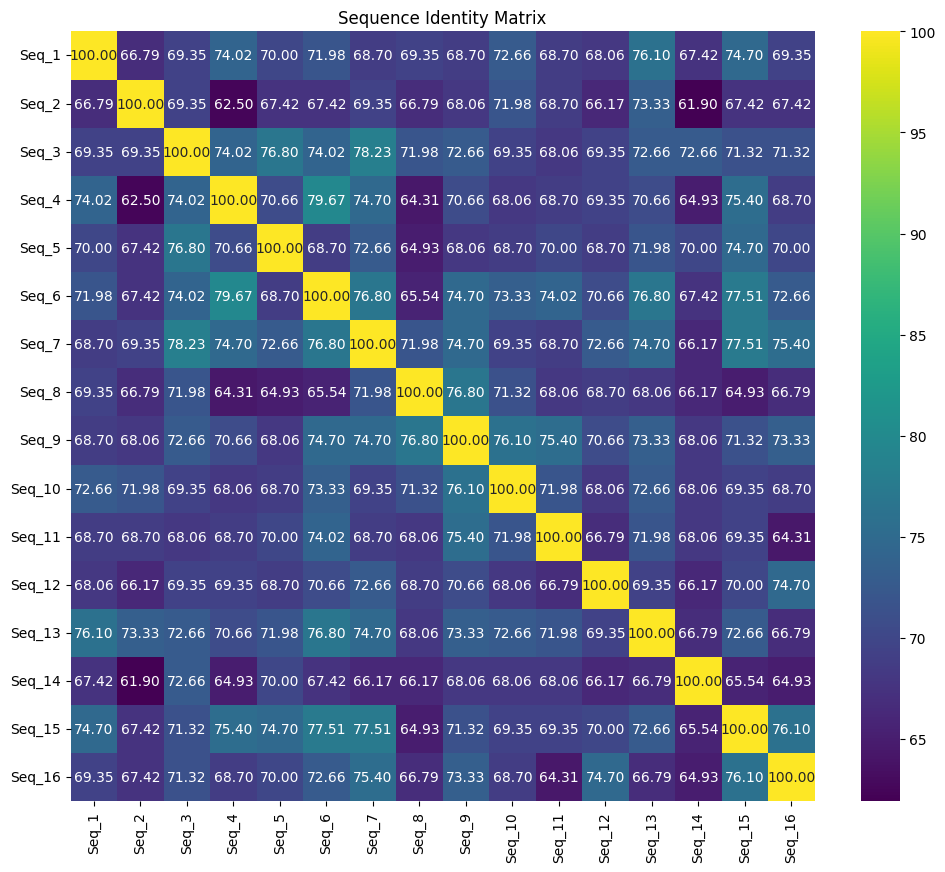

In [ ]:
# calculate the sequence similarity between all the designed sequences
# and show them as a similarity matrix

num_sequences = len(sequences)
identity_matrix = np.zeros((num_sequences, num_sequences))

for i in range(num_sequences):
    for j in range(num_sequences):
        identity_matrix[i, j] = calculate_sequence_identity(sequences[i], sequences[j])

# Create a DataFrame for visualization
sequence_names = [f"Seq_{i+1}" for i in range(num_sequences)] #sequence names
identity_df = pd.DataFrame(identity_matrix, index=sequence_names, columns=sequence_names)

# Visualize with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(identity_df, annot=True, cmap="viridis", fmt=".2f")
plt.title("Sequence Identity Matrix")
plt.show()

In [ ]:
multiple_lines = """
design:0 n:0 mpnn:0.820 plddt:0.389 ptm:0.378 pae:20.597 rmsd:17.180
design:0 n:1 mpnn:0.827 plddt:0.750 ptm:0.781 pae:9.328 rmsd:5.184
design:0 n:2 mpnn:0.828 plddt:0.456 ptm:0.416 pae:19.062 rmsd:14.993
design:0 n:3 mpnn:0.814 plddt:0.370 ptm:0.360 pae:20.875 rmsd:18.308
design:0 n:4 mpnn:0.814 plddt:0.417 ptm:0.388 pae:19.331 rmsd:16.366
design:0 n:5 mpnn:0.825 plddt:0.715 ptm:0.754 pae:10.052 rmsd:4.571
design:0 n:6 mpnn:0.815 plddt:0.513 ptm:0.572 pae:16.250 rmsd:7.617
design:0 n:7 mpnn:0.810 plddt:0.447 ptm:0.488 pae:18.321 rmsd:18.996
design:0 n:8 mpnn:0.812 plddt:0.782 ptm:0.803 pae:8.629 rmsd:2.529
design:0 n:9 mpnn:0.821 plddt:0.397 ptm:0.394 pae:20.140 rmsd:16.664
design:0 n:10 mpnn:0.831 plddt:0.785 ptm:0.797 pae:8.303 rmsd:2.826
design:0 n:11 mpnn:0.815 plddt:0.411 ptm:0.397 pae:19.102 rmsd:18.222
design:0 n:12 mpnn:0.800 plddt:0.721 ptm:0.764 pae:10.136 rmsd:4.963
design:0 n:13 mpnn:0.817 plddt:0.505 ptm:0.492 pae:17.276 rmsd:8.013
design:0 n:14 mpnn:0.827 plddt:0.736 ptm:0.758 pae:10.110 rmsd:5.425
design:0 n:15 mpnn:0.809 plddt:0.386 ptm:0.415 pae:19.496 rmsd:16.401 """


In [ ]:
data_string = "design:0 n:0 mpnn:0.801 plddt:0.712 ptm:0.743 pae:10.510 rmsd:5.030"

def parse_data_for_pandas(data_str):
    """Parses the data string into a dictionary for pandas."""
    data_dict = {}
    parts = data_str.split()
    for part in parts:
        key, value = part.split(":")
        try:
            data_dict[key] = float(value)
        except ValueError:
            try:
                data_dict[key] = int(value)
            except ValueError:
                data_dict[key] = value
    return data_dict

data_lines = multiple_lines.strip().splitlines()
all_data = []

for line in data_lines:
    all_data.append(parse_data_for_pandas(line))

df = pd.DataFrame(all_data)

# Accessing data:
print(df["mpnn"][0])  # Output: 0.801
print(df["design"][1]) #Output 1
print(df) #prints the whole dataframe.

0.82
0.0
    design     n   mpnn  plddt    ptm     pae    rmsd
0      0.0   0.0  0.820  0.389  0.378  20.597  17.180
1      0.0   1.0  0.827  0.750  0.781   9.328   5.184
2      0.0   2.0  0.828  0.456  0.416  19.062  14.993
3      0.0   3.0  0.814  0.370  0.360  20.875  18.308
4      0.0   4.0  0.814  0.417  0.388  19.331  16.366
5      0.0   5.0  0.825  0.715  0.754  10.052   4.571
6      0.0   6.0  0.815  0.513  0.572  16.250   7.617
7      0.0   7.0  0.810  0.447  0.488  18.321  18.996
8      0.0   8.0  0.812  0.782  0.803   8.629   2.529
9      0.0   9.0  0.821  0.397  0.394  20.140  16.664
10     0.0  10.0  0.831  0.785  0.797   8.303   2.826
11     0.0  11.0  0.815  0.411  0.397  19.102  18.222
12     0.0  12.0  0.800  0.721  0.764  10.136   4.963
13     0.0  13.0  0.817  0.505  0.492  17.276   8.013
14     0.0  14.0  0.827  0.736  0.758  10.110   5.425
15     0.0  15.0  0.809  0.386  0.415  19.496  16.401


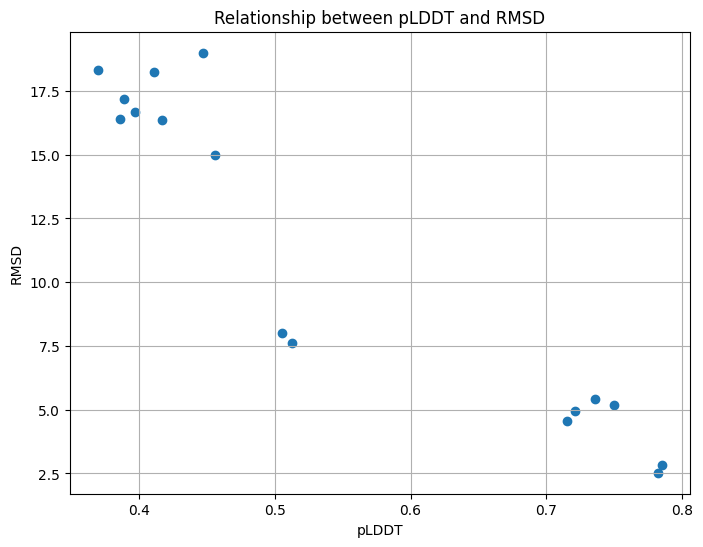

In [ ]:
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.scatter(df["plddt"], df["rmsd"])  # Create a scatter plot
plt.title("Relationship between pLDDT and RMSD")
plt.xlabel("pLDDT")
plt.ylabel("RMSD")
plt.grid(True)  # Add gridlines (optional)
plt.show()

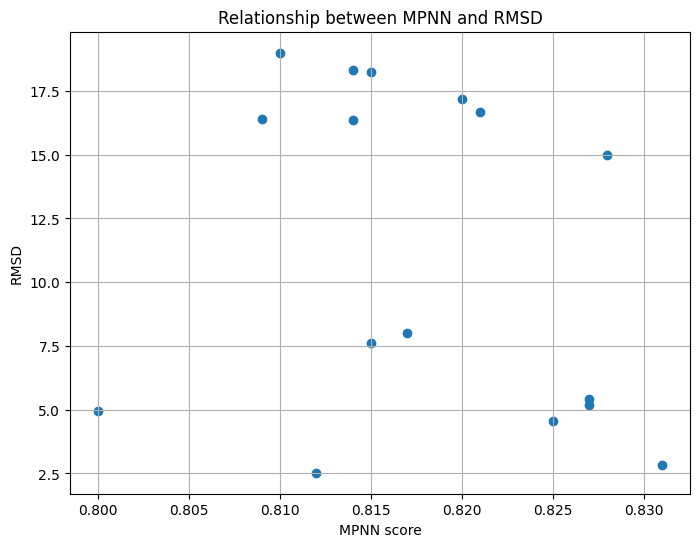

In [ ]:
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.scatter(df["mpnn"], df["rmsd"])  # Create a scatter plot
plt.title("Relationship between MPNN and RMSD")
plt.xlabel("MPNN score")
plt.ylabel("RMSD")
plt.grid(True)  # Add gridlines (optional)
plt.show()

In [ ]:
from Bio.PDB import PDBParser, PPBuilder
from Bio import SeqIO
from io import StringIO

In [ ]:
def get_sequence_from_pdb(pdb_file_path):
    """
    Extracts the protein sequence from a PDB file.

    Args:
        pdb_file_path (str): Path to the PDB file.

    Returns:
        str: The protein sequence, or None if an error occurs.
    """
    try:
        parser = PDBParser(QUIET=True)  # Suppress warnings
        structure = parser.get_structure("protein", pdb_file_path)
        ppb = PPBuilder()  # Peptide builder

        sequences = []
        for model in structure:
            for chain in model:
                for pp in ppb.build_peptides(chain):
                    sequences.append(str(pp.get_sequence()))

        if sequences:
            return "".join(sequences)  # Concatenate sequences if multiple chains
        else:
            return None  # No sequence found

    except Exception as e:
        print(f"Error processing PDB file: {e}")
        return None

def get_sequence_from_pdb_string(pdb_string):
    """
    Extracts the protein sequence from a PDB string.

    Args:
        pdb_string (str): The PDB file contents as a string.

    Returns:
        str: The protein sequence, or None if an error occurs.
    """
    try:
        parser = PDBParser(QUIET=True)
        structure = parser.get_structure("protein", StringIO(pdb_string))
        ppb = PPBuilder()

        sequences = []
        for model in structure:
            for chain in model:
                for pp in ppb.build_peptides(chain):
                    sequences.append(str(pp.get_sequence()))

        if sequences:
            return "".join(sequences)
        else:
            return None

    except Exception as e:
        print(f"Error processing PDB string: {e}")
        return None

# Example Usage (from file):
pdb_file = "1lvm_cleaned.pdb"  # Replace with your PDB file path
sequence = get_sequence_from_pdb(pdb_file)

if sequence:
    print("Protein Sequence:", sequence)
else:
    print("Could not extract sequence.")



Protein Sequence: GESLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKHLFRRNNGTLLVQSLHGVFKVKNTTTLQQHLIDGRDMIIIRMPKDFPPFPQKLKFREPQREERICLVTTNFQTKSMSSMVSDTSCTFPSSDGIFWKHWIQTKDGQCGSPLVSTRDGFIVGIHSASNFTNTNNYFTSVPKNFMELLTNQEAQQWVSGWRLNADSVLWGGHKVFMDKP


In [ ]:
wild_type_sequence = "GESLFKGPRDYNPISSTICHLTNESDGHTTSLYGIGFGPFIITNKHLFRRNNGTLLVQSLHGVFKVKNTTTLQQHLIDGRDMIIIRMPKDFPPFPQKLKFREPQREERICLVTTNFQTKSMSSMVSDTSCTFPSSDGIFWKHWIQTKDGQCGSPLVSTRDGFIVGIHSASNFTNTNNYFTSVPKNFMELLTNQEAQQWVSGWRLNADSVLWGGHKVFMDKP"

In [ ]:
identities = []
for designed_seq in sequences:
    identity = calculate_sequence_identity(wild_type_sequence, designed_seq)
    identities.append(identity)

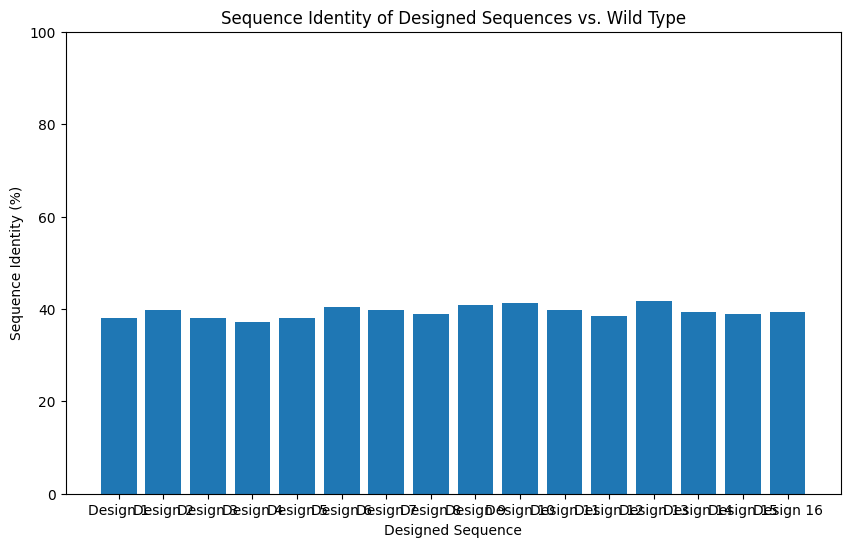

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(range(len(sequences)), identities)
plt.xticks(range(len(sequences)), [f"Design {i+1}" for i in range(len(sequences))])
plt.xlabel("Designed Sequence")
plt.ylabel("Sequence Identity (%)")
plt.title("Sequence Identity of Designed Sequences vs. Wild Type")
plt.ylim(0, 100) #set y limits to 0 and 100.
plt.show()


#### All of the designs are about 40% sequence identity to the wild type. We held 28 residues fixed when designing the protein, which is only about 13% of the total sequence. This suggests that there are maybe other areas of the protein where the sequence is conserved between designs!

## [EXERCISE 2]

In [ ]:
%%time
#@title run **RFdiffusion** to generate de novo backbones
name = "test"
contigs = "150" #This will make a 100 residue protein by default. See instructions below
pdb = "" #You can specify an input PDB for motif scaffolding
iterations = 50 #This normally should not be changed
num_designs = 3 #How many designs to generate
visual = "image" #["none", "image", "interactive"]

#symmetry settings
symmetry = "auto" #["none", "auto", "cyclic", "dihedral"]
order = 1 # 1 is not symmetric i.e. C1
chains = ""
add_potential = True

# determine where to save
path = name
while os.path.exists(f"outputs/{path}_0.pdb"):
  path = name + "_" + ''.join(random.choices(string.ascii_lowercase + string.digits, k=5))

flags = {"contigs":contigs,
         "pdb":pdb,
         "order":order,
         "iterations":iterations,
         "symmetry":symmetry,
         "hotspot":"",
         "path":path,
         "chains":chains,
         "add_potential":add_potential,
         "num_designs":num_designs,
         "visual":visual}

for k,v in flags.items():
  if isinstance(v,str):
    flags[k] = v.replace("'","").replace('"','')

contigs, copies = run_diffusion(**flags)

mode: free
output: outputs/test_mr80s
contigs: ['150-150']
./RFdiffusion/run_inference.py inference.output_prefix=outputs/test_mr80s inference.num_designs=3 diffuser.T=50 'contigmap.contigs=[150-150]' inference.dump_pdb=True inference.dump_pdb_path='/dev/shm'


CPU times: user 16 s, sys: 320 ms, total: 16.3 s
Wall time: 3min 15s


### The shorter proteins (25 - 50 residues) was mostly just long helices. When I used the template motif of a protein I work with regularly, and it designed a protein that looked overall similar in structure but didn't have any diversity in secondary structure, there were really only helices connected by short loops, no beta sheets were present.

In [ ]:
#time is in seconds
multiple_lines = """
residues:190 time:281
residues:25 time:131
residues:50 time:129
residues:100 time:132
residues:125 time:161
residues:150 time:195
"""


In [ ]:
data_string = "residues:190 time:281"

def parse_data_for_pandas(data_str):
    """Parses the data string into a dictionary for pandas."""
    data_dict = {}
    parts = data_str.split()
    for part in parts:
        key, value = part.split(":")
        try:
            data_dict[key] = float(value)
        except ValueError:
            try:
                data_dict[key] = int(value)
            except ValueError:
                data_dict[key] = value
    return data_dict

data_lines = multiple_lines.strip().splitlines()
all_data = []

for line in data_lines:
    all_data.append(parse_data_for_pandas(line))

df = pd.DataFrame(all_data)

# Accessing data:
print(df["residues"][0])  # Output: 0.801
print(df["time"][1]) #Output 1
print(df) #prints the whole dataframe.

190.0
131.0
   residues   time
0     190.0  281.0
1      25.0  131.0
2      50.0  129.0
3     100.0  132.0
4     125.0  161.0
5     150.0  195.0


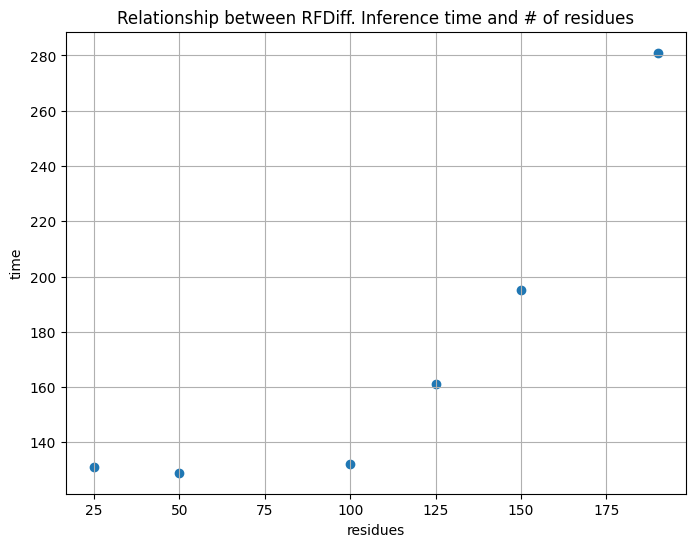

In [ ]:
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
plt.scatter(df["residues"], df["time"])  # Create a scatter plot
plt.title("Relationship between RFDiff. Inference time and # of residues")
plt.xlabel("residues")
plt.ylabel("time")
plt.grid(True)  # Add gridlines (optional)
plt.show()

#### Inference time only starts going up after 100 residues!

In [ ]:
#@title Display 3D structure {run: "auto"}
animate = "none" #@param ["none", "movie", "interactive"]
color = "plddt" #@param ["rainbow", "chain", "plddt"]
denoise = True
dpi = 100 #@param ["100", "200", "400"] {type:"raw"}
from colabdesign.shared.plot import pymol_color_list
from colabdesign.rf.utils import get_ca, get_Ls, make_animation
from string import ascii_uppercase,ascii_lowercase
alphabet_list = list(ascii_uppercase+ascii_lowercase)

def plot_pdb(num=0):
  if denoise:
    pdb_traj = f"outputs/traj/{path}_{num}_pX0_traj.pdb"
  else:
    pdb_traj = f"outputs/traj/{path}_{num}_Xt-1_traj.pdb"
  if animate in ["none","interactive"]:
    hbondCutoff = 4.0
    view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
    if animate == "interactive":
      pdb_str = open(pdb_traj,'r').read()
      view.addModelsAsFrames(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
    else:
      pdb = f"outputs/{path}_{num}.pdb"
      pdb_str = open(pdb,'r').read()
      view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
    if color == "rainbow":
      view.setStyle({'cartoon': {'color':'spectrum'}})
    elif color == "chain":
      for n,chain,c in zip(range(len(contigs)),
                              alphabet_list,
                              pymol_color_list):
          view.setStyle({'chain':chain},{'cartoon': {'color':c}})
    else:
      view.setStyle({'cartoon': {'colorscheme': {'prop':'b','gradient': 'roygb','min':0.5,'max':0.9}}})
    view.zoomTo()
    if animate == "interactive":
      view.animate({'loop': 'backAndForth'})
    view.show()
  else:
    Ls = get_Ls(contigs)
    xyz, bfact = get_ca(pdb_traj, get_bfact=True)
    xyz = xyz.reshape((-1,sum(Ls),3))[::-1]
    bfact = bfact.reshape((-1,sum(Ls)))[::-1]
    if color == "chain":
      display(HTML(make_animation(xyz, Ls=Ls, dpi=dpi, ref=-1)))
    elif color == "rainbow":
      display(HTML(make_animation(xyz, dpi=dpi, ref=-1)))
    else:
      display(HTML(make_animation(xyz, plddt=bfact*100, dpi=dpi, ref=-1)))


if num_designs > 1:
  output = widgets.Output()
  def on_change(change):
    if change['name'] == 'value':
      with output:
        output.clear_output(wait=True)
        plot_pdb(change['new'])
  dropdown = widgets.Dropdown(
      options=[(f'{k}',k) for k in range(num_designs)],
      value=0, description='design:',
  )
  dropdown.observe(on_change)
  display(widgets.VBox([dropdown, output]))
  with output:
    plot_pdb(dropdown.value)
else:
  plot_pdb()

## [EXERCISE 3]

In [ ]:
%%time
#@title run **RFdiffusion** to generate de novo backbones
name = "exercise3"
contigs = "60-100" #This will make a 100 residue protein by default. See instructions below
pdb = "" #You can specify an input PDB for motif scaffolding
iterations = 50 #This normally should not be changed
num_designs = 15 #How many designs to generate
visual = "image" #["none", "image", "interactive"]

#symmetry settings
symmetry = "auto" #["none", "auto", "cyclic", "dihedral"]
order = 1 # 1 is not symmetric i.e. C1
chains = ""
add_potential = True

# determine where to save
path = name
while os.path.exists(f"outputs/{path}_0.pdb"):
  path = name + "_" + ''.join(random.choices(string.ascii_lowercase + string.digits, k=5))

flags = {"contigs":contigs,
         "pdb":pdb,
         "order":order,
         "iterations":iterations,
         "symmetry":symmetry,
         "hotspot":"",
         "path":path,
         "chains":chains,
         "add_potential":add_potential,
         "num_designs":num_designs,
         "visual":visual}

for k,v in flags.items():
  if isinstance(v,str):
    flags[k] = v.replace("'","").replace('"','')

contigs, copies = run_diffusion(**flags)

mode: free
output: outputs/exercise3_rmvbo
contigs: ['97-97']
./RFdiffusion/run_inference.py inference.output_prefix=outputs/exercise3_rmvbo inference.num_designs=15 diffuser.T=50 'contigmap.contigs=[97-97]' inference.dump_pdb=True inference.dump_pdb_path='/dev/shm'


CPU times: user 1min 6s, sys: 1.48 s, total: 1min 7s
Wall time: 10min 9s


In [ ]:
%%time
#@title run **ProteinMPNN** and **AlphaFold** on RFdiffusion backbones
#ProteinMPNN Settings
num_seqs = 2
mpnn_sampling_temp = 0.1 # control diversity of sampled sequences. (higher = more diverse).
rm_aa = "C" #do not use [C]ysteines

#AlphaFold Settings
num_recycles = 3 # How many times alphafold will refine the predicted structure

if not os.path.isfile("params/done.txt"):
  print("downloading AlphaFold params...")
  while not os.path.isfile("params/done.txt"):
    time.sleep(5)

contigs_str = ":".join(contigs)

opts = [f"--pdb=outputs/{path}_0.pdb",
        f"--loc=outputs/{path}",
        f"--contig={contigs_str}",
        f"--copies={copies}",
        f"--num_seqs={num_seqs}",
        f"--num_recycles={num_recycles}",
        f"--rm_aa={rm_aa}",
        f"--mpnn_sampling_temp={mpnn_sampling_temp}",
        f"--num_designs={num_designs}"]

opts = ' '.join(opts)
!python colabdesign/rf/designability_test.py {opts}

{'pdb':'outputs/exercise3_rmvbo_0.pdb','loc':'outputs/exercise3_rmvbo','contigs':'97-97','copies':1,'num_seqs':2,'initial_guess':False,'use_multimer':False,'use_soluble':False,'num_recycles':3,'rm_aa':'C','num_designs':15,'mpnn_sampling_temp':0.1}
protocol=fixbb
running proteinMPNN...
running AlphaFold...
design:0 n:0 mpnn:1.100 plddt:0.924 ptm:0.808 pae:3.529 rmsd:0.761 SLEEEKKEILEYAKEVLEKLKPEIEVDESLTKEEVEERLERLKKKIKEGKATLEEIKEAAAQVASYIVNKEIEDYEELKKYYEELEELLKIIEERLK
design:0 n:1 mpnn:1.015 plddt:0.901 ptm:0.754 pae:4.188 rmsd:0.833 MEEEEKKKILEEAKKVLEELKKEIEVDESLTKEEVKKKKEEIKKKIKEGTATLEELKETAAQVASYIVNKEIKDFEELKEYYEFLKELKKKIKELEE
design:1 n:0 mpnn:1.124 plddt:0.910 ptm:0.750 pae:3.961 rmsd:0.842 ASPELKERLEKLEEFLKRLEAIKELPPEERVPALIELLRELLEFLKEDPEVPEELVEEVEELLERLERERSEEVAEEVLERARKLVEELIKELKKKI
design:1 n:1 mpnn:1.050 plddt:0.932 ptm:0.803 pae:3.129 rmsd:0.468 VSPELAARLARLEAALARARAIRALPPEERLPALEELLAEVAAWLRADPSVPAELVAEVEALLAELRERGDEATADAVLDRLEALLEALIAELRAKA
design:2 n:0 mpnn:0.980 plddt:0.9

In [ ]:
multiple_lines = """
design:0 n:0 mpnn:1.100 plddt:0.924 ptm:0.808 pae:3.529 rmsd:0.761 sequence:SLEEEKKEILEYAKEVLEKLKPEIEVDESLTKEEVEERLERLKKKIKEGKATLEEIKEAAAQVASYIVNKEIEDYEELKKYYEELEELLKIIEERLK
design:0 n:1 mpnn:1.015 plddt:0.901 ptm:0.754 pae:4.188 rmsd:0.833 sequence:MEEEEKKKILEEAKKVLEELKKEIEVDESLTKEEVKKKKEEIKKKIKEGTATLEELKETAAQVASYIVNKEIKDFEELKEYYEFLKELKKKIKELEE
design:1 n:0 mpnn:1.124 plddt:0.910 ptm:0.750 pae:3.961 rmsd:0.842 sequence:ASPELKERLEKLEEFLKRLEAIKELPPEERVPALIELLRELLEFLKEDPEVPEELVEEVEELLERLERERSEEVAEEVLERARKLVEELIKELKKKI
design:1 n:1 mpnn:1.050 plddt:0.932 ptm:0.803 pae:3.129 rmsd:0.468 sequence:VSPELAARLARLEAALARARAIRALPPEERLPALEELLAEVAAWLRADPSVPAELVAEVEALLAELRERGDEATADAVLDRLEALLEALIAELRAKA
design:2 n:0 mpnn:0.980 plddt:0.918 ptm:0.755 pae:3.667 rmsd:0.507 sequence:SMEEKEAIEKLRKFLKEMGFSEEEIETLLEVVKEKAKISGKPLVEQIKEFMEKLEKYKGDKEKIVKLLEEWLKELKKAGAPEEFLKRVEELIKKVKE
design:2 n:1 mpnn:1.066 plddt:0.945 ptm:0.811 pae:2.710 rmsd:0.760 sequence:SAAEEAAIAELRALLAAMGFSEEEIEILLEIVKEMAKISGKPLVEQIAEFMARLRAAAGDTEAIVAMLEGLLKELEKAGAPEEFLERVKELAARVRA
design:3 n:0 mpnn:0.977 plddt:0.932 ptm:0.786 pae:3.410 rmsd:0.548 sequence:EELLEEAEELLKRLEEMKSLPLEERLKEAKELLKEVKKLIEKAKDLPEEIQKELKKIEKTLKELIKDLEEGPENAEELLKKAIEEVKKLIELLKKEL
design:3 n:1 mpnn:1.018 plddt:0.929 ptm:0.778 pae:3.478 rmsd:0.477 sequence:EKLLKKVKELLKRVKEMKTLPLEEQLKELEELAKELKKLLKEAKNLPEKIQEALKKALKLAEEAIKDLKTGPKNLEALLKELAKALEELAKLLEEEL
design:4 n:0 mpnn:1.091 plddt:0.790 ptm:0.568 pae:7.340 rmsd:9.651 sequence:SLEEKKELIEEYEKALEEAKALRAEVEKRGLLTPELKAKEKELEAKLKEYEKKLKELGDKLKLSKELIKELLELAKELKAALEKLLAAAKAAEAAAA
design:4 n:1 mpnn:1.128 plddt:0.842 ptm:0.701 pae:5.499 rmsd:1.362 sequence:SSAEKEAALAELEEARARREELLAEVEARGWLTPELRALQAELDAKLAELEAALAAAGDPLALSLALIEEALELAREAVAALEALLAEQEAAEAAAA
design:5 n:0 mpnn:1.107 plddt:0.943 ptm:0.821 pae:2.907 rmsd:0.690 sequence:LEALLAELATKSALEIFETLARLAEEHPERLPELKALFDALAPLLREQLATEYGLSPAEIDALLAELRAAFDAGREAAIATLRAVAARLRALEEERA
design:5 n:1 mpnn:1.071 plddt:0.892 ptm:0.695 pae:4.567 rmsd:0.657 sequence:MEELLKKLETKSALEIFKELEKLAKENPELLEEIKEIFLKLEPKLREQFKTELGLSDEEIEKILKELKEAFEKGLEEFIKKLKELAEEIEKLLKEKE
design:6 n:0 mpnn:0.984 plddt:0.900 ptm:0.703 pae:4.916 rmsd:0.697 sequence:MKKREEIKKKLEEILKKVKKMKKEVEAYLKLGNEALKKELEELKKKLEKLEKKIKELLKELEKLSLEEAEKKLKELEKELKELEKEFKKLKEKLEKE
design:6 n:1 mpnn:1.001 plddt:0.893 ptm:0.700 pae:5.087 rmsd:0.650 sequence:MEEKEKIKKELEKMLEEAKKMAKEVKALLATGNKALAAELKALLKELEAFIEEIEKLLKELEKLSLEERKKRLKELKKKLEALKKKLAALKKRAAAL
design:7 n:0 mpnn:1.042 plddt:0.901 ptm:0.750 pae:4.146 rmsd:0.885 sequence:MEEVEVAVAEEEEEAEAIKKEALEKGKNLVLVILHEDGTVEIIYINAKTGEEERKTIKLPKETAKKVAEELLKLNGEKDWEKLLKKIEEIIEKALKE
design:7 n:1 mpnn:1.012 plddt:0.906 ptm:0.761 pae:4.046 rmsd:0.827 sequence:MEEVEVAVAKEEEEYEKIKKEALEKGKRLVLVKLKEDGTVIIEYIDAKTGKEEKKEVKLSKEDAEALAKKLLELNGEKDWEEALKKIEELIKEVEKK
design:8 n:0 mpnn:1.156 plddt:0.933 ptm:0.790 pae:3.079 rmsd:0.446 sequence:DELVERAEEFRRELLARFREAGFPEEDIAAVDALLDAHIAALRAGDYEAALAAMDELLALVKEIAARLDPETAERLTAWVEERLAELRERLRELKEA
design:8 n:1 mpnn:1.225 plddt:0.927 ptm:0.761 pae:3.242 rmsd:0.635 sequence:SELVEEAKELREEFLERAEELGFPEADREELEKLMEEFIKYLEAGDVEAALKAMEELEKLVEERAASLPEEDAEEFVEWVRKALEEIRKRLKELVEA
design:9 n:0 mpnn:1.165 plddt:0.919 ptm:0.779 pae:3.501 rmsd:0.511 sequence:MSLEEKEELLIELIEELYEENPEEMEKYILEGNFEKIIELILELAEEDEEILELVEEYLEEHEERVKELLEFLSEEYKKTGDFEESIKKVREYVKKK
design:9 n:1 mpnn:1.210 plddt:0.922 ptm:0.789 pae:3.349 rmsd:0.481 sequence:MSLKEKAELLLEIIEAVYKENPEEFGKLILEGNFEGIKEMILEYAAKDPEKLAELLEFYEEHSELVEEIFKFLSEQYKETGNFEESIEKTREWIEKK
design:10 n:0 mpnn:0.965 plddt:0.562 ptm:0.400 pae:14.136 rmsd:3.550 sequence:AAAAAAAEAEAALRAAVAALLAALGAPAEFAPAVLAIRRRFAADPAFAEELARAHLAERLTGDRAAYRAAVAAAIAALPPERAARARALLAALAAAA
design:10 n:1 mpnn:1.036 plddt:0.764 ptm:0.573 pae:8.045 rmsd:2.178 sequence:GLAALAAAAEAALRAAVKALLAELGAPEALAPAALALRKRFAENPEFAEELVRAHLRMALTGDRAAEEAALAAAIARLPPEEAARARAALEALRAAA
design:11 n:0 mpnn:1.035 plddt:0.914 ptm:0.754 pae:3.734 rmsd:0.537 sequence:EELLEELKKFSEEILKRLKEAGVPEEEIEKIKELLEEIEELIKKKEELPLEELLKKIEEKYKEIIEILKEYGLEEEAKKVEERLKKIKEWLKEEEAK
design:11 n:1 mpnn:1.103 plddt:0.898 ptm:0.715 pae:4.310 rmsd:0.738 sequence:SELLEKAEKLFKEILEALKEAGAPEEVIEKVEELLEKIKEVIKEREKLPLEETLKKIRELFEEIIKILKELGLEELAKKVREFEKELEEYLKKKEKE
design:12 n:0 mpnn:0.960 plddt:0.924 ptm:0.767 pae:3.891 rmsd:0.893 sequence:EEEKLKEELKKTLEELKKLIKKLREEYGKEELVEELEEILKKLEKGEVDEEEIKELEERIKELEEKKKKGELTEEELLELEAYKLALEAMKLLKKLK
design:12 n:1 mpnn:1.037 plddt:0.924 ptm:0.769 pae:3.757 rmsd:0.640 sequence:KKEELEEKLKELKEELEKLVEELLEEYGLEELAEEAREILKLIEEGKVDEEKLKELEKKIKELEKLKKEGKLTEEGEKKLELYELLKEALELLKKLK
design:13 n:0 mpnn:1.132 plddt:0.878 ptm:0.691 pae:5.410 rmsd:0.879 sequence:MPEEEKERMEKLIEETLEKVKESVEKFIEEEKKKGNKVEVKEEDGKLIITITKETEEEKLTVKITIDLEKGFTVKIEVTIEYKDGTVLSLSREEEIK
design:13 n:1 mpnn:1.066 plddt:0.794 ptm:0.529 pae:11.062 rmsd:10.834 sequence:MPEELLKEMKELMEEYLEKVKKSIEELIKEEKEKGKKVKIKEEDGKLIIEIKEKTPEKEIKVIIEIDLKKGFKVKIKVIIKYKDGTEYELEKEVEEE
design:14 n:0 mpnn:1.032 plddt:0.936 ptm:0.818 pae:2.878 rmsd:0.544 sequence:RIALIVVVTRLDPALRAALEALAAEHPDVELILREAPAAEQEAVLEALRAEAEAAGVAVVSLAVDLDPDATPEELAATTAAVVAEARAQLAAARAAL
design:14 n:1 mpnn:1.014 plddt:0.910 ptm:0.764 pae:3.824 rmsd:0.628 sequence:KIVVIVVVTREHPLLVKAVKELAEKNPEVELIIKQAPEEEMDKVLEELEKKYKEKGYKVVSIKVVLKEDLTPEEIEKITEEVVKELEEKIEEAKKEI
"""


In [ ]:

def parse_data_for_pandas(data_str):
    """Parses the data string into a dictionary for pandas."""
    data_dict = {}
    parts = data_str.split()
    for part in parts:
        key, value = part.split(":")
        try:
            data_dict[key] = float(value)
        except ValueError:
            try:
                data_dict[key] = int(value)
            except ValueError:
                data_dict[key] = value
    return data_dict

data_lines = multiple_lines.strip().splitlines()
all_data = []

for line in data_lines:
    all_data.append(parse_data_for_pandas(line))

df = pd.DataFrame(all_data)

df['length'] = df['sequence'].str.len()

# Accessing data:
print(df["plddt"][4])  # Output: 0.801
print(df["n"][1]) #Output 1
print(df) #prints the whole dataframe.

0.918
1.0
    design    n   mpnn  plddt    ptm     pae    rmsd  \
0      0.0  0.0  1.100  0.924  0.808   3.529   0.761   
1      0.0  1.0  1.015  0.901  0.754   4.188   0.833   
2      1.0  0.0  1.124  0.910  0.750   3.961   0.842   
3      1.0  1.0  1.050  0.932  0.803   3.129   0.468   
4      2.0  0.0  0.980  0.918  0.755   3.667   0.507   
5      2.0  1.0  1.066  0.945  0.811   2.710   0.760   
6      3.0  0.0  0.977  0.932  0.786   3.410   0.548   
7      3.0  1.0  1.018  0.929  0.778   3.478   0.477   
8      4.0  0.0  1.091  0.790  0.568   7.340   9.651   
9      4.0  1.0  1.128  0.842  0.701   5.499   1.362   
10     5.0  0.0  1.107  0.943  0.821   2.907   0.690   
11     5.0  1.0  1.071  0.892  0.695   4.567   0.657   
12     6.0  0.0  0.984  0.900  0.703   4.916   0.697   
13     6.0  1.0  1.001  0.893  0.700   5.087   0.650   
14     7.0  0.0  1.042  0.901  0.750   4.146   0.885   
15     7.0  1.0  1.012  0.906  0.761   4.046   0.827   
16     8.0  0.0  1.156  0.933  0.790  

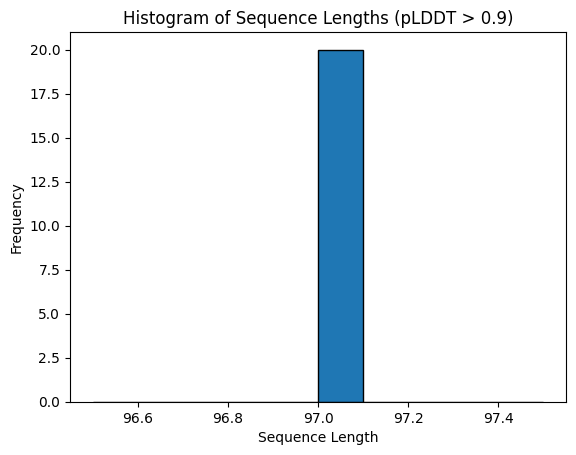

In [ ]:
# Filter for plddt > 0.9
high_plddt = df[df['plddt'] > 0.9]

# Create the histogram
plt.hist(high_plddt['length'], bins=10, edgecolor='black')  # You can adjust the number of bins
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.title('Histogram of Sequence Lengths (pLDDT > 0.9)')
plt.show()

### For some reason, all of my sequences are 97 amino acids long.

In [ ]:
#@title Display best result
import py3Dmol
def plot_pdb(num = "best"):
  if num == "best":
    with open(f"outputs/{path}/best.pdb","r") as f:
      # REMARK 001 design {m} N {n} RMSD {rmsd}
      info = f.readline().strip('\n').split()
    num = info[3]
  hbondCutoff = 4.0
  view = py3Dmol.view(js='https://3dmol.org/build/3Dmol.js')
  pdb_str = open(f"outputs/{path}_{num}.pdb",'r').read()
  view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})
  pdb_str = open(f"outputs/{path}/best_design{num}.pdb",'r').read()
  view.addModel(pdb_str,'pdb',{'hbondCutoff':hbondCutoff})

  view.setStyle({"model":0},{'cartoon':{}}) #: {'colorscheme': {'prop':'b','gradient': 'roygb','min':0,'max':100}}})
  view.setStyle({"model":1},{'cartoon':{'colorscheme': {'prop':'b','gradient': 'roygb','min':0,'max':100}}})
  view.zoomTo()
  view.show()

if num_designs > 1:
  def on_change(change):
    if change['name'] == 'value':
      with output:
        output.clear_output(wait=True)
        plot_pdb(change['new'])
  dropdown = widgets.Dropdown(
    options=["best"] + [str(k) for k in range(num_designs)],
    value="best",
    description='design:',
  )
  dropdown.observe(on_change)
  output = widgets.Output()
  display(widgets.VBox([dropdown, output]))
  with output:
    plot_pdb(dropdown.value)
else:
  plot_pdb()

In [ ]:
#@title Package and download results
#@markdown If you are having issues downloading the result archive,
#@markdown try disabling your adblocker and run this cell again.
#@markdown  If that fails click on the little folder icon to the
#@markdown  left, navigate to file: `name.result.zip`,
#@markdown  right-click and select \"Download\"
#@markdown (see [screenshot](https://pbs.twimg.com/media/E6wRW2lWUAEOuoe?format=jpg&name=small)).
!zip -r {path}.result.zip outputs/{path}* outputs/traj/{path}*
files.download(f"{path}.result.zip")

**Instructions**
---
---

Use `contigs` to define continious chains. Use a `:` to define multiple contigs and a `/` to define mutliple segments within a contig.
For example:

**unconditional**
- `contigs='100'` - diffuse **monomer** of length 100
- `contigs='50:100'` - diffuse **hetero-oligomer** of lengths 50 and 100
- `contigs='50'` `symmetry='cyclic'` `order=2` - make two copies of the defined contig(s) and add a symmetry constraint, for **homo-oligomeric** diffusion.

**binder design**
- `contigs='A:50'` `pdb='4N5T'` - diffuse a **binder** of length 50 to chain A of defined PDB.
- `contigs='E6-155:70-100'` `pdb='5KQV'` `hotspot='E64,E88,E96'` - diffuse a **binder** of length 70 to 100 (sampled randomly) to chain E and defined hotspot(s).

**motif scaffolding**
 - `contigs='40/A163-181/40'` `pdb='5TPN'`
 - `contigs='A3-30/36/A33-68'` `pdb='6MRR'` - diffuse a loop of length 36 between two segments of defined PDB ranges.

*hints and tips*
- `pdb=''` leave blank to get an upload prompt
- `contigs='50-100'` use dash to specify a range of lengths to sample from